# 🔥 FLAME 3 — Análisis: Fine-tuning LFM2.5-VL-450M

Este notebook documenta y permite reproducir el pipeline completo de fine-tuning de un Vision-Language Model
sobre imágenes aéreas de incendios del dataset **FLAME 3 Sycan Marsh**.

**Celdas ejecutables de a una:**
0. 🎓 Tutorial — qué es SFT y cómo funciona (esta sección)
1. 📉 Curvas de entrenamiento
2. 📊 Tabla comparativa base vs fine-tuned
3. 🤖 Eval en vivo sobre imágenes reales
4. 🔍 Análisis de errores
5. 📦 Distribución del dataset
6. 🖼️ Plots guardados

---
## 0. 🎓 Tutorial: Post-training con SFT

### ¿Qué es el post-training?

Los LLMs se entrenan primero en cantidades masivas de texto genérico (**pre-training**).
Después de eso, el modelo sabe "hablar" pero no sabe hacer tareas específicas con el formato correcto.
El **post-training** es el proceso de afinar ese modelo base para que sea útil en una tarea concreta.

### ¿Qué técnica usamos? → Supervised Fine-Tuning (SFT)

SFT es la técnica más directa: le mostramos al modelo **miles de ejemplos (input → output correcto)**
y lo entrenamos para que aprenda a replicar esa respuesta minimizando el error.

En nuestro caso:
- **Input**: system prompt + imagen RGB + imagen Thermal + pregunta
- **Output esperado**: JSON estructurado con 5 campos de análisis de incendio

### Diagrama del proceso — Post-training con SFT

```mermaid
flowchart TD
    subgraph DATA["📦 Dataset — 738 escenas FLAME 3"]
        direction LR
        A1["RGB Corrected FOV"]
        A2["Thermal Raw JPG"]
        A3["Celsius TIFF (ground truth térmica)"]
    end

    subgraph LABELS["🏷️ Generación de Labels automática"]
        B1["generate_labels.py lee Celsius TIFF"]
        B2["Deriva 5 campos:\n• fire_present\n• thermal_hotspot_intensity\n• fire_size\n• smoke_visible\n• image_quality_limited"]
    end

    subgraph SPLIT["✂️ Split estratificado 80/20"]
        C1["Train: 591 escenas\n498 Fire / 93 No Fire"]
        C2["Test: 147 escenas\n124 Fire / 23 No Fire"]
    end

    subgraph JSONL["📄 Formato VLM SFT — leap-finetune"]
        D1["train.jsonl 591 filas\nsystem + user con imgs + assistant JSON"]
    end

    subgraph SFT["🏋️ Supervised Fine-Tuning — Full FT sin LoRA"]
        E1["LFM2.5-VL-450M base"]
        E2["leap-finetune · Ray Train · HF Trainer"]
        E3["H100 80GB · 3 epochs · 105 steps\nBatch efectivo 16 · LR 2e-5 cosine"]
        E4["Loss: 0.24 → 0.028  (8.4x mejora)"]
        E1 --> E2 --> E3 --> E4
    end

    subgraph EVAL["📊 Evaluación — test set 147 samples"]
        F1["Base:  overall 0.21"]
        F2["Fine-tuned:  overall 0.86"]
        F3["Δ = +0.65  (4.1x mejor)"]
        F1 -.->|mejora| F2 --> F3
    end

    DATA --> LABELS --> SPLIT --> JSONL --> SFT --> EVAL

    style SFT    fill:#dbeafe,stroke:#1d4ed8
    style EVAL   fill:#dcfce7,stroke:#16a34a
    style DATA   fill:#fef9c3,stroke:#ca8a04
    style LABELS fill:#fce7f3,stroke:#db2777
    style SPLIT  fill:#f3e8ff,stroke:#9333ea
    style JSONL  fill:#ffedd5,stroke:#ea580c
```

---
### ¿Qué ve el modelo en cada paso del entrenamiento?

En cada step, el modelo recibe **una muestra** del `train.jsonl`.  
Cada muestra tiene exactamente esta estructura:

```
┌─────────────────────────────────────────────────────────────┐
│ ROLE: system                                                 │
│   "Eres un asistente de visión para monitoreo de incendios. │
│    Dado un par de imágenes RGB + Thermal, retorna un JSON   │
│    con: fire_present, thermal_hotspot_intensity, ..."        │
├─────────────────────────────────────────────────────────────┤
│ ROLE: user                                                   │
│   [imagen RGB]  ← 640×512 px, cámara óptica corregida       │
│   [imagen Thermal] ← 640×512 px, sensor IR                  │
│   "Image 1 is the RGB. Image 2 is the thermal.              │
│    Return the wildfire JSON for this scene."                 │
├─────────────────────────────────────────────────────────────┤
│ ROLE: assistant  ← esto es lo que el modelo debe predecir   │
│   {"fire_present": true,                                     │
│    "thermal_hotspot_intensity": "high",                      │
│    "fire_size": "medium",                                    │
│    "smoke_visible": true,                                    │
│    "image_quality_limited": false}                           │
└─────────────────────────────────────────────────────────────┘
```

La loss se calcula **solo sobre los tokens del assistant** (el JSON).  
El modelo no es penalizado por system ni user — solo aprende a generar la respuesta correcta dada la entrada.

/tmp/ipykernel_48804/3764825592.py:85: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.savefig(str(FT_DIR/"evals"/"plots"/"00_training_sample.png"), dpi=130, bbox_inches="tight")
/tmp/ipykernel_48804/3764825592.py:85: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  plt.savefig(str(FT_DIR/"evals"/"plots"/"00_training_sample.png"), dpi=130, bbox_inches="tight")


/home/manuel-labbe/miniconda3/envs/ecosmart/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/manuel-labbe/miniconda3/envs/ecosmart/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


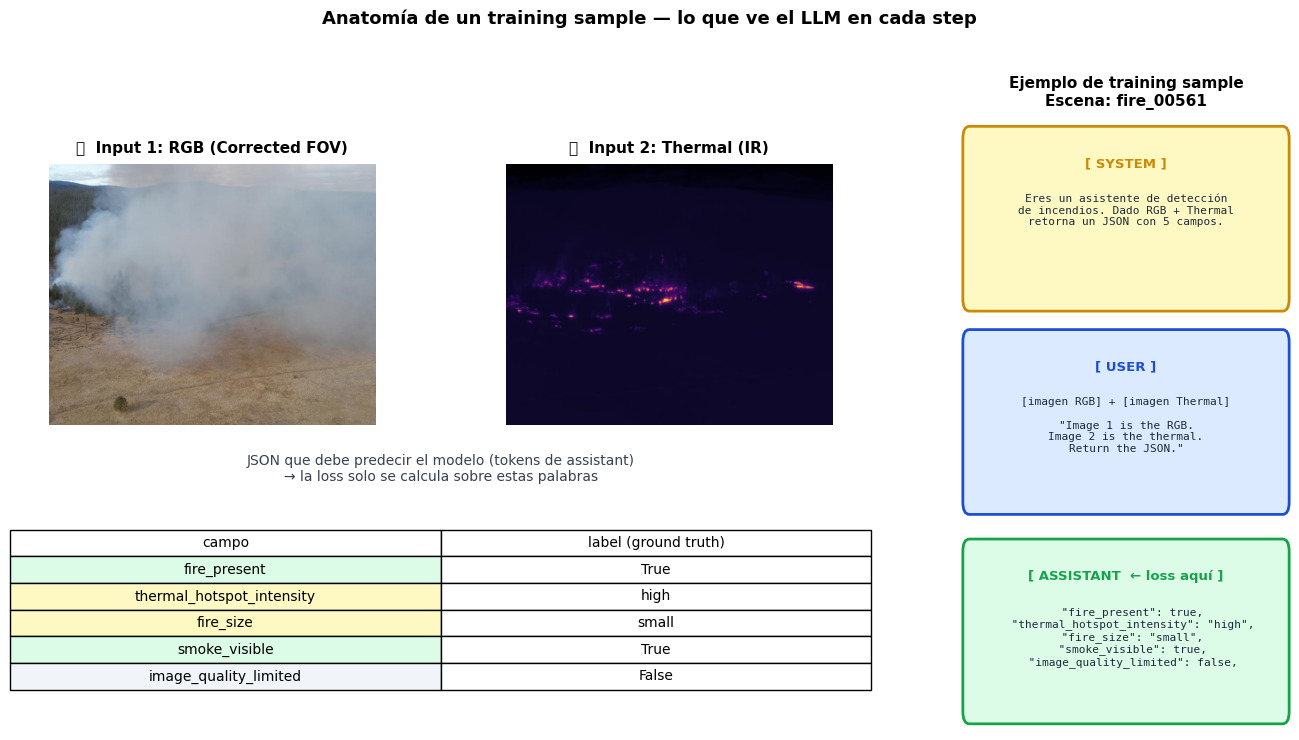

Escena: fire_00561
Total tokens approx input: 2310 chars


In [2]:
# Mostrar un ejemplo REAL de training sample
import json, sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

ROOT      = Path(".")
FT_DIR    = ROOT / "flame3_finetune"
IMAGES_DIR = FT_DIR / "data" / "images"

# Tomar la primera muestra del train.jsonl
train_rows = [json.loads(l) for l in (FT_DIR/"data"/"train.jsonl").read_text().splitlines() if l.strip()]
sample = train_rows[0]

user_content = sample["messages"][1]["content"]
scene_id     = user_content[0]["image"].replace("_rgb.jpg","")
system_text  = sample["messages"][0]["content"][0]["text"]
user_text    = user_content[2]["text"]
gt_json      = json.loads(sample["messages"][2]["content"][0]["text"])

rgb = Image.open(IMAGES_DIR / f"{scene_id}_rgb.jpg")
thr = Image.open(IMAGES_DIR / f"{scene_id}_thermal.jpg")

# ── Visualización ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 8))
gs  = fig.add_gridspec(2, 3, height_ratios=[1.5, 1], hspace=0.05, wspace=0.4)

# Imágenes
ax_rgb = fig.add_subplot(gs[0, 0])
ax_thr = fig.add_subplot(gs[0, 1])
ax_rgb.imshow(rgb); ax_rgb.axis("off")
ax_rgb.set_title("📷  Input 1: RGB (Corrected FOV)", fontsize=11, fontweight="bold", pad=8)
ax_thr.imshow(thr); ax_thr.axis("off")
ax_thr.set_title("🌡️  Input 2: Thermal (IR)", fontsize=11, fontweight="bold", pad=8)

# Flechas SYSTEM / USER / ASSISTANT
ax_flow = fig.add_subplot(gs[:, 2])
ax_flow.axis("off")

blocks = [
    (0.95, "#fef9c3", "#ca8a04", "SYSTEM", 
     "Eres un asistente de detección\nde incendios. Dado RGB + Thermal\nretorna un JSON con 5 campos."),
    (0.62, "#dbeafe", "#1d4ed8", "USER",   
     f"[imagen RGB] + [imagen Thermal]\n\n\"Image 1 is the RGB.\nImage 2 is the thermal.\nReturn the JSON.\""),
    (0.28, "#dcfce7", "#16a34a", "ASSISTANT  ← loss aquí", 
     "\n".join(f'  "{k}": {json.dumps(v)},' for k,v in gt_json.items())),
]

for y, bg, border, role, text in blocks:
    ax_flow.add_patch(mpatches.FancyBboxPatch(
        (0.02, y-0.25), 0.96, 0.26,
        boxstyle="round,pad=0.02", linewidth=2,
        edgecolor=border, facecolor=bg, transform=ax_flow.transAxes, clip_on=False
    ))
    ax_flow.text(0.5, y-0.02, f"[ {role} ]", transform=ax_flow.transAxes,
                 ha="center", va="top", fontsize=9.5, fontweight="bold", color=border)
    ax_flow.text(0.5, y-0.08, text, transform=ax_flow.transAxes,
                 ha="center", va="top", fontsize=8, color="#1e293b",
                 fontfamily="monospace", wrap=True)

ax_flow.set_title(f"Ejemplo de training sample\nEscena: {scene_id}", 
                  fontsize=11, fontweight="bold")

# Tabla del output
ax_tbl = fig.add_subplot(gs[1, :2])
ax_tbl.axis("off")
field_colors = {
    "fire_present": "#dcfce7", "thermal_hotspot_intensity": "#fef9c3",
    "fire_size": "#fef9c3", "smoke_visible": "#dcfce7", "image_quality_limited": "#f1f5f9"
}
table_data = [[k, str(v)] for k, v in gt_json.items()]
tbl = ax_tbl.table(
    cellText=table_data,
    colLabels=["campo", "label (ground truth)"],
    cellLoc="center", loc="center",
    cellColours=[[field_colors.get(row[0], "white"), "white"] for row in table_data]
)
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.1, 1.6)
ax_tbl.set_title("JSON que debe predecir el modelo (tokens de assistant)\n→ la loss solo se calcula sobre estas palabras",
                 fontsize=10, color="#374151", pad=6)

plt.suptitle("Anatomía de un training sample — lo que ve el LLM en cada step",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig(str(FT_DIR/"evals"/"plots"/"00_training_sample.png"), dpi=130, bbox_inches="tight")
plt.show()
print(f"Escena: {scene_id}")
print(f"Total tokens approx input: {len(str(sample))} chars")


---
### ¿Cómo actualiza el modelo sus pesos?

En cada step el Trainer hace esto:

1. **Forward pass**: el modelo recibe las imágenes + texto y genera una predicción
2. **Loss**: compara la predicción con el JSON correcto (cross-entropy)
3. **Backward pass**: calcula el gradiente del error respecto a cada peso
4. **Optimizer step**: actualiza los pesos en la dirección que reduce el error

Después de **105 steps** (3 epochs × 35 steps/epoch), el modelo pasó de:
- No saber emitir los 5 campos → **100% campos presentes**
- Loss 0.24 → **0.028** (8.4x mejor)
- Overall accuracy 0.21 → **0.86** (4.1x mejor)

---


In [3]:
# ─── Configuración de paths ───────────────────────────────────────────────────
from pathlib import Path

ROOT        = Path(".")  # raíz del proyecto (donde está este notebook)
FT_DIR      = ROOT / "flame3_finetune"
MODEL_DIR   = FT_DIR / "model_finetuned"
BASE_MODEL  = "LiquidAI/LFM2.5-VL-450M"
IMAGES_DIR  = FT_DIR / "data" / "images"
EVALS_DIR   = FT_DIR / "evals"
PLOTS_DIR   = EVALS_DIR / "plots"

# Verificar que todo existe
for p in [FT_DIR, MODEL_DIR, IMAGES_DIR, EVALS_DIR]:
    status = "✅" if p.exists() else "❌"
    print(f"{status} {p}")

✅ flame3_finetune
✅ flame3_finetune/model_finetuned
✅ flame3_finetune/data/images
✅ flame3_finetune/evals


---
## 1. Curvas de entrenamiento

In [4]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Cargar trainer_state.json
state = json.loads((EVALS_DIR / "trainer_state.json").read_text())
train_log = [e for e in state["log_history"] if "loss" in e]
eval_log  = [e for e in state["log_history"] if "eval_loss" in e]

print(f"Training steps: {len(train_log)}")
print(f"Eval checkpoints: {len(eval_log)}")
print(f"Total epochs: {state['num_train_epochs']}")
print(f"Max steps: {state['max_steps']}")

Training steps: 22
Eval checkpoints: 4
Total epochs: 3
Max steps: 105


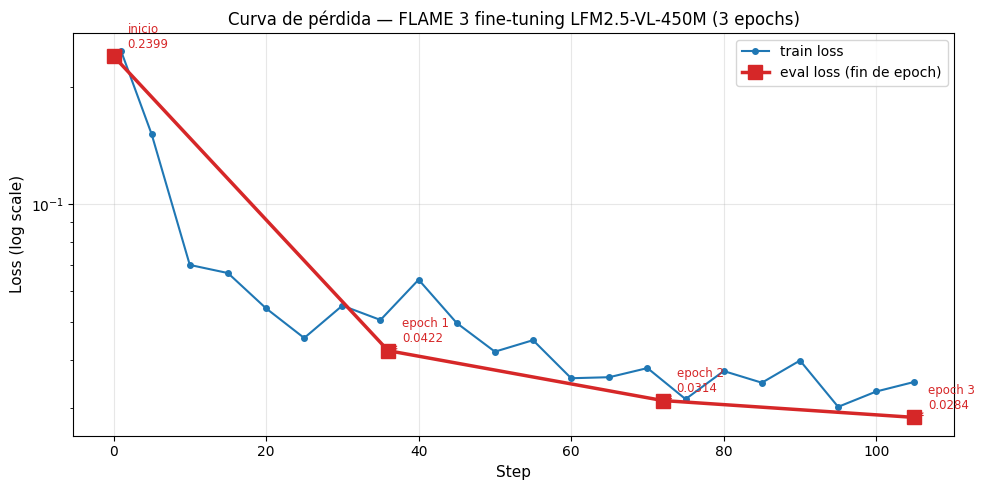

Loss inicial: 0.2399  →  Loss final: 0.0284  (8.4x mejora)


In [5]:
# ─── Loss curve (train + eval) ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

steps_train = [e["step"] for e in train_log]
loss_train  = [e["loss"] for e in train_log]
steps_eval  = [e["step"] for e in eval_log]
loss_eval   = [e["eval_loss"] for e in eval_log]

ax.plot(steps_train, loss_train, marker="o", ms=4, lw=1.5,
        color="#1f77b4", label="train loss")
ax.plot(steps_eval, loss_eval, marker="s", ms=10, lw=2.5,
        color="#d62728", label="eval loss (fin de epoch)")

# Anotar cada eval
for i, e in enumerate(eval_log):
    label = "inicio" if e["step"] == 0 else f"epoch {i}"
    ax.annotate(f"{label}\n{e['eval_loss']:.4f}",
                xy=(e["step"], e["eval_loss"]),
                xytext=(10, 6), textcoords="offset points",
                fontsize=8.5, color="#d62728",
                arrowprops=dict(arrowstyle="->", color="#d62728", lw=0.8))

ax.set_yscale("log")
ax.set_xlabel("Step", fontsize=11)
ax.set_ylabel("Loss (log scale)", fontsize=11)
ax.set_title("Curva de pérdida — FLAME 3 fine-tuning LFM2.5-VL-450M (3 epochs)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Loss inicial: {loss_eval[0]:.4f}  →  Loss final: {loss_eval[-1]:.4f}  ({loss_eval[0]/loss_eval[-1]:.1f}x mejora)")

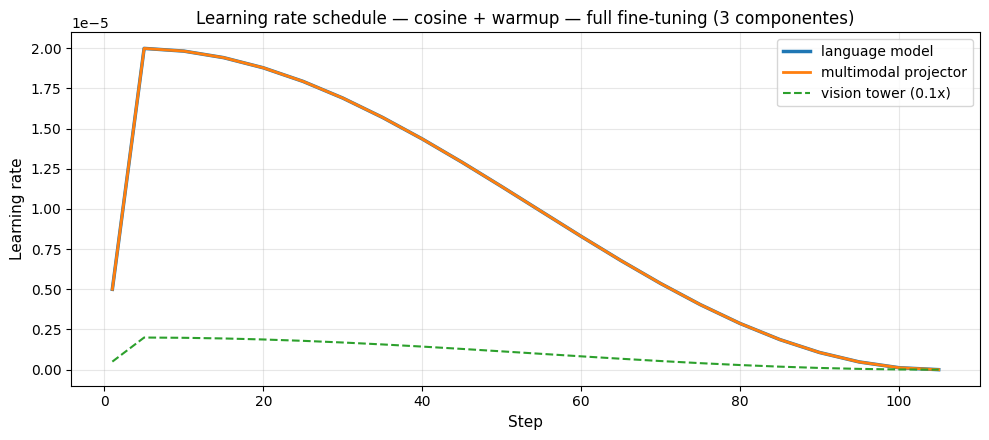

In [6]:
# ─── Learning rate schedule ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(steps_train, [e["lr/language_model"]        for e in train_log], lw=2.5, label="language model")
ax.plot(steps_train, [e["lr/multi_modal_projector"] for e in train_log], lw=2,   label="multimodal projector")
ax.plot(steps_train, [e["lr/vision_tower"]          for e in train_log], lw=1.5, label="vision tower (0.1x)", linestyle="--")

ax.set_xlabel("Step", fontsize=11)
ax.set_ylabel("Learning rate", fontsize=11)
ax.set_title("Learning rate schedule — cosine + warmup — full fine-tuning (3 componentes)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

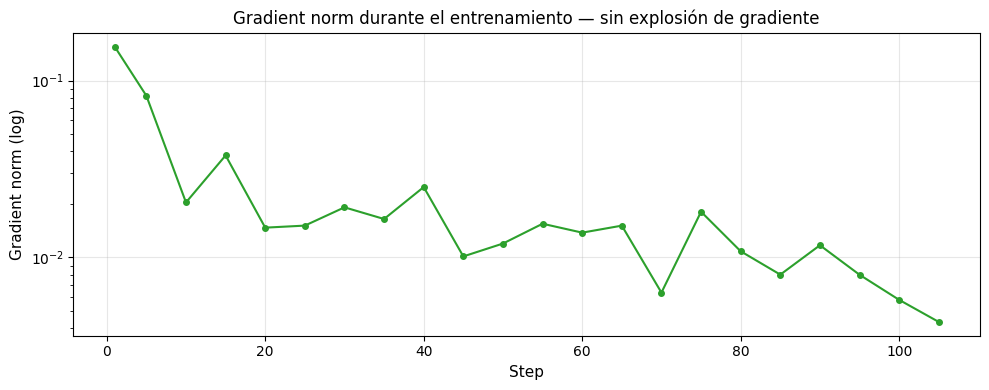

Grad norm máx: 0.1558  |  mín: 0.0043


In [7]:
# ─── Gradient norm ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(steps_train, [e["grad_norm"] for e in train_log],
        marker="o", ms=4, lw=1.5, color="#2ca02c")

ax.set_yscale("log")
ax.set_xlabel("Step", fontsize=11)
ax.set_ylabel("Gradient norm (log)", fontsize=11)
ax.set_title("Gradient norm durante el entrenamiento — sin explosión de gradiente", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Grad norm máx: {max(e['grad_norm'] for e in train_log):.4f}  |  mín: {min(e['grad_norm'] for e in train_log):.4f}")

---
## 2. Tabla comparativa: base vs fine-tuned

In [8]:
import pandas as pd

base_meta = json.loads((EVALS_DIR / "base"      / "meta.json").read_text())
ft_meta   = json.loads((EVALS_DIR / "finetuned" / "meta.json").read_text())

fields = ["valid_json", "fields_present", "fire_present",
          "thermal_hotspot_intensity", "fire_size",
          "smoke_visible", "image_quality_limited"]

rows = []
for f in fields:
    b = base_meta["per_field"][f]
    ft = ft_meta["per_field"][f]
    rows.append({"campo": f, "base": f"{b:.2f}", "fine-tuned": f"{ft:.2f}",
                 "Δ": f"+{ft-b:.2f}" if ft >= b else f"{ft-b:.2f}"})

rows.append({"campo": "⭐ overall",
             "base": f"{base_meta['overall']:.2f}",
             "fine-tuned": f"{ft_meta['overall']:.2f}",
             "Δ": f"+{ft_meta['overall']-base_meta['overall']:.2f}"})
rows.append({"campo": "⏱ avg latency (s)",
             "base": f"{base_meta['avg_latency_s']:.2f}",
             "fine-tuned": f"{ft_meta['avg_latency_s']:.2f}",
             "Δ": f"{ft_meta['avg_latency_s']-base_meta['avg_latency_s']:+.2f}"})

df = pd.DataFrame(rows).set_index("campo")
print(f"Test set: {base_meta['n']} samples\n")
df.style.set_properties(**{"text-align": "center"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "center")]}]
)

Test set: 147 samples



,base,fine-tuned,Δ
campo,,,
valid_json,1.00,1.00,+0.00
fields_present,0.05,1.00,+0.95
fire_present,0.84,1.00,+0.16
thermal_hotspot_intensity,0.12,0.82,+0.70
fire_size,0.03,0.53,+0.50
smoke_visible,0.04,0.99,+0.95
image_quality_limited,0.00,0.96,+0.96
⭐ overall,0.21,0.86,+0.65
⏱ avg latency (s),0.26,0.42,+0.16


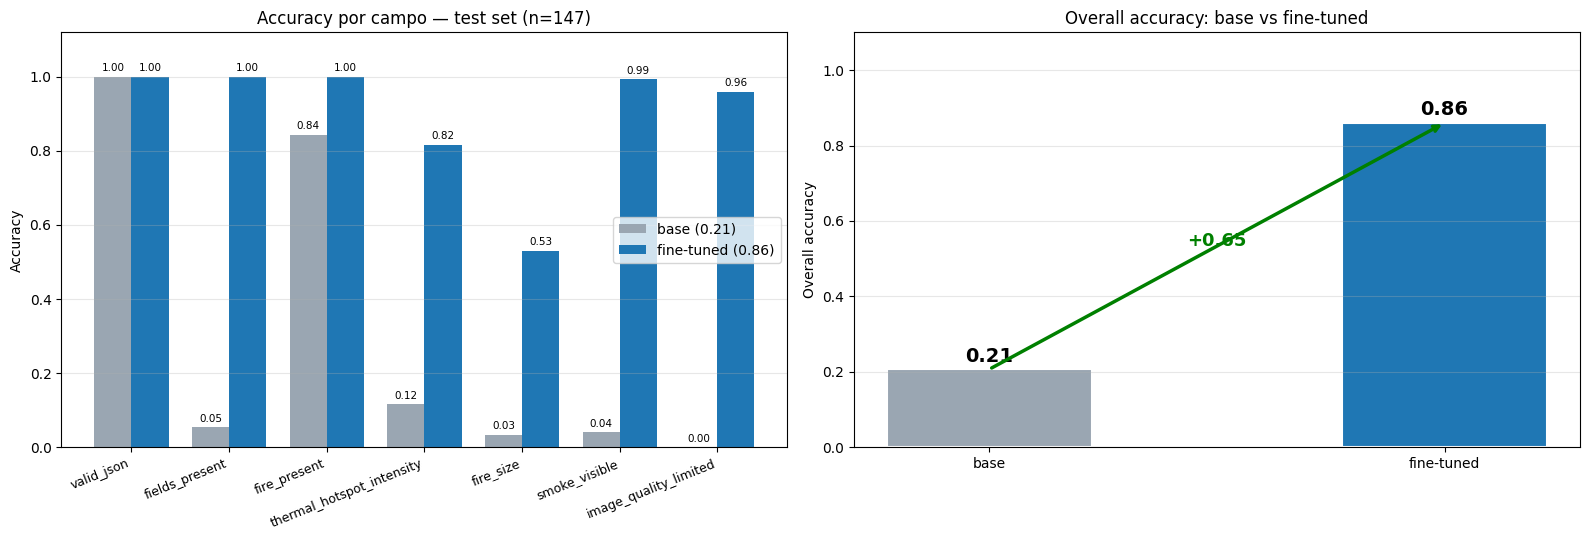

In [9]:
# ─── Gráfico de barras comparativo ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

base_vals = [base_meta["per_field"][f] for f in fields]
ft_vals   = [ft_meta["per_field"][f]   for f in fields]
x = np.arange(len(fields))
w = 0.38

# Panel izq: side-by-side
ax = axes[0]
bars_b  = ax.bar(x - w/2, base_vals, w, label=f"base ({base_meta['overall']:.2f})",      color="#9aa6b2")
bars_ft = ax.bar(x + w/2, ft_vals,   w, label=f"fine-tuned ({ft_meta['overall']:.2f})",  color="#1f77b4")
ax.set_xticks(x)
ax.set_xticklabels(fields, rotation=22, ha="right", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy por campo — test set (n=147)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
for bar, v in list(zip(bars_b, base_vals)) + list(zip(bars_ft, ft_vals)):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.015, f"{v:.2f}",
            ha="center", fontsize=7.5)

# Panel der: overall summary
ax2 = axes[1]
bars2 = ax2.bar(["base", "fine-tuned"],
                [base_meta["overall"], ft_meta["overall"]],
                color=["#9aa6b2", "#1f77b4"], width=0.45,
                edgecolor="white", linewidth=1.5)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel("Overall accuracy")
ax2.set_title("Overall accuracy: base vs fine-tuned")
ax2.grid(True, axis="y", alpha=0.3)
for bar, v in zip(bars2, [base_meta["overall"], ft_meta["overall"]]):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.02,
             f"{v:.2f}", ha="center", fontsize=14, fontweight="bold")
ax2.annotate("", xy=(1, ft_meta["overall"]), xytext=(0, base_meta["overall"]),
             arrowprops=dict(arrowstyle="->", color="green", lw=2.5))
ax2.text(0.5, (base_meta["overall"] + ft_meta["overall"])/2,
         f"+{ft_meta['overall']-base_meta['overall']:.2f}",
         ha="center", fontsize=13, color="green", fontweight="bold")

plt.tight_layout()
plt.show()

---
## 3. Eval en vivo sobre imágenes del test set

> **Nota**: El modelo se carga en CPU (sin GPU). La inferencia tarda ~5-10s por imagen. Si tienes GPU disponible, cambia `device_map='cpu'` por `device_map='auto'`.

In [10]:
import sys, torch, time
sys.path.insert(0, str(FT_DIR / "scripts"))
from prompts import SYSTEM_PROMPT, USER_TEXT, FIELDS
from transformers import AutoProcessor, AutoModelForImageTextToText

print("Cargando modelo fine-tuned...")
t0 = time.time()
processor = AutoProcessor.from_pretrained(str(MODEL_DIR), trust_remote_code=True)
model = AutoModelForImageTextToText.from_pretrained(
    str(MODEL_DIR), dtype=torch.float32, device_map="cpu", trust_remote_code=True
)
model.eval()
print(f"Listo en {time.time()-t0:.1f}s")

Cargando modelo fine-tuned...


Loading weights:   0%|          | 0/350 [00:00<?, ?it/s]

Listo en 2.9s


In [11]:
import json as _json
from PIL import Image
import IPython.display as ipd

def infer(scene_id: str) -> dict:
    """Corre inferencia del modelo FT sobre una escena y muestra el resultado."""
    rgb_path = IMAGES_DIR / f"{scene_id}_rgb.jpg"
    thr_path = IMAGES_DIR / f"{scene_id}_thermal.jpg"

    rgb = Image.open(rgb_path).convert("RGB")
    thr = Image.open(thr_path).convert("RGB")

    # Mostrar imágenes
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(rgb);  axes[0].set_title("RGB (Corrected FOV)");  axes[0].axis("off")
    axes[1].imshow(thr);  axes[1].set_title("Thermal (Raw JPG)");    axes[1].axis("off")
    plt.suptitle(f"Escena: {scene_id}", fontsize=12)
    plt.tight_layout(); plt.show()

    messages = [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT.strip()}]},
        {"role": "user",   "content": [
            {"type": "image", "image": rgb},
            {"type": "image", "image": thr},
            {"type": "text",  "text": USER_TEXT},
        ]},
    ]
    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=True, tokenize=True
    )
    t0 = time.time()
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=128, do_sample=False)
    dt = time.time() - t0
    text = processor.batch_decode(out[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True)[0]

    try:
        pred = _json.loads(text[text.find("{"):text.rfind("}")+1])
    except Exception:
        pred = {"raw": text}

    print(f"⏱ Latencia: {dt:.2f}s")
    print(f"🤖 Predicción: {_json.dumps(pred, indent=2)}")
    return pred

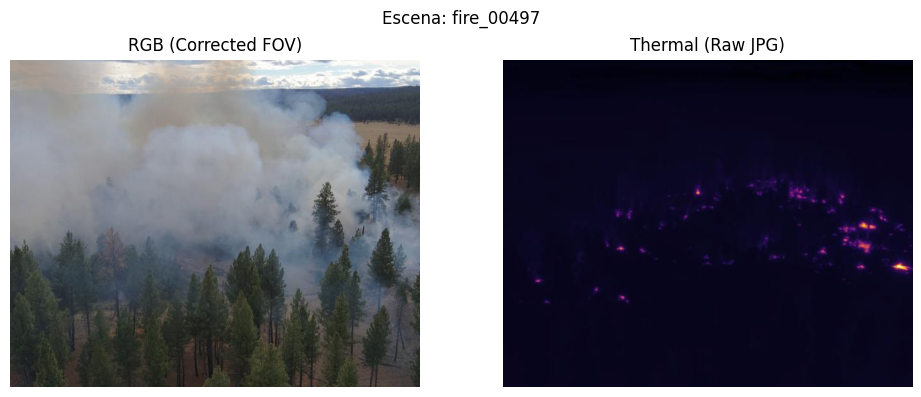

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


⏱ Latencia: 5.27s
🤖 Predicción: {
  "fire_present": true,
  "thermal_hotspot_intensity": "high",
  "fire_size": "medium",
  "smoke_visible": true,
  "image_quality_limited": false
}


In [12]:
# ─── Probar con una escena Fire ───────────────────────────────────────────────
pred = infer("fire_00497")

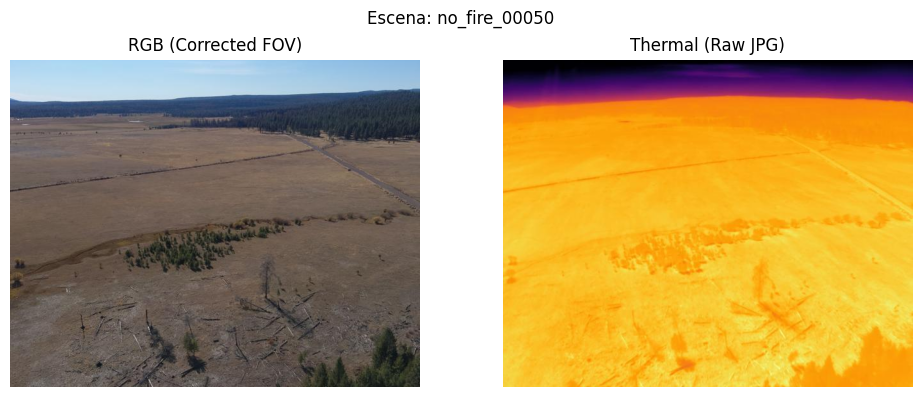

⏱ Latencia: 5.20s
🤖 Predicción: {
  "fire_present": false,
  "thermal_hotspot_intensity": "none",
  "fire_size": "none",
  "smoke_visible": false,
  "image_quality_limited": false
}


In [13]:
# ─── Probar con una escena No Fire ────────────────────────────────────────────
pred = infer("no_fire_00050")

In [14]:
# ─── Batch eval: N escenas aleatorias del test set ────────────────────────────
import random, time

test_rows = [_json.loads(l) for l in (FT_DIR / "data" / "test.jsonl").read_text().splitlines() if l.strip()]

N = 10  # ← cambia este número para evaluar más o menos escenas
sample = random.sample(test_rows, N)

results, latencies = [], []
for row in sample:
    user_content = row["messages"][1]["content"]
    scene = user_content[0]["image"].rsplit("_rgb.jpg", 1)[0]
    truth = _json.loads(row["messages"][2]["content"][0]["text"])

    rgb = Image.open(IMAGES_DIR / f"{scene}_rgb.jpg").convert("RGB")
    thr = Image.open(IMAGES_DIR / f"{scene}_thermal.jpg").convert("RGB")
    messages = [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT.strip()}]},
        {"role": "user",   "content": [
            {"type": "image", "image": rgb}, {"type": "image", "image": thr},
            {"type": "text",  "text": USER_TEXT},
        ]},
    ]
    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=True, tokenize=True
    )
    t0 = time.time()
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=128, do_sample=False)
    dt = time.time() - t0
    latencies.append(dt)
    text = processor.batch_decode(out[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True)[0]
    try:
        pred = _json.loads(text[text.find("{"):text.rfind("}")+1])
    except Exception:
        pred = {}
    per = {f: int(pred.get(f) == truth.get(f)) for f in FIELDS}
    results.append({"scene": scene, "truth": truth, "pred": pred, "per": per, "latency": dt})
    print(f"  {scene:30s}  overall={sum(per.values())/len(per):.2f}  {dt:.1f}s")

overall = sum(sum(r["per"].values()) for r in results) / (len(results) * len(FIELDS))
print(f"\n{'─'*55}")
print(f"  Overall en {N} samples:  {overall:.3f}")
print(f"  Latencia promedio:     {sum(latencies)/len(latencies):.2f}s")
print(f"  Latencia mínima:       {min(latencies):.2f}s")
print(f"  Latencia máxima:       {max(latencies):.2f}s")

  fire_00582                      overall=0.60  5.2s


  fire_00603                      overall=0.80  5.3s


  fire_00415                      overall=1.00  5.3s


  fire_00246                      overall=0.80  5.3s


  fire_00231                      overall=0.80  5.3s


  no_fire_00007                   overall=1.00  5.2s


  fire_00288                      overall=1.00  5.3s


  fire_00078                      overall=1.00  5.3s


  fire_00567                      overall=0.60  5.3s


  fire_00435                      overall=0.80  5.3s

───────────────────────────────────────────────────────
  Overall en 10 samples:  0.840
  Latencia promedio:     5.27s
  Latencia mínima:       5.22s
  Latencia máxima:       5.32s


---
## 4. Análisis de errores del test set completo

In [15]:
# Cargar resultados guardados del eval completo
ft_results = _json.loads((EVALS_DIR / "finetuned" / "results.json").read_text())

# Errores por campo
from collections import Counter

errors = {f: [] for f in FIELDS}
for r in ft_results:
    for f in FIELDS:
        if r["per_field"].get(f) == 0:
            errors[f].append(r)

print("Errores por campo en el test set (147 samples):")
print(f"{'campo':<30} {'errores':>8} {'accuracy':>10}")
print("─" * 52)
for f in FIELDS:
    n_err = len(errors[f])
    acc = 1 - n_err / len(ft_results)
    print(f"{f:<30} {n_err:>8}   {acc:>9.2f}")

Errores por campo en el test set (147 samples):
campo                           errores   accuracy
────────────────────────────────────────────────────
fire_present                          0        1.00
thermal_hotspot_intensity            27        0.82
fire_size                            69        0.53
smoke_visible                         1        0.99
image_quality_limited                 6        0.96


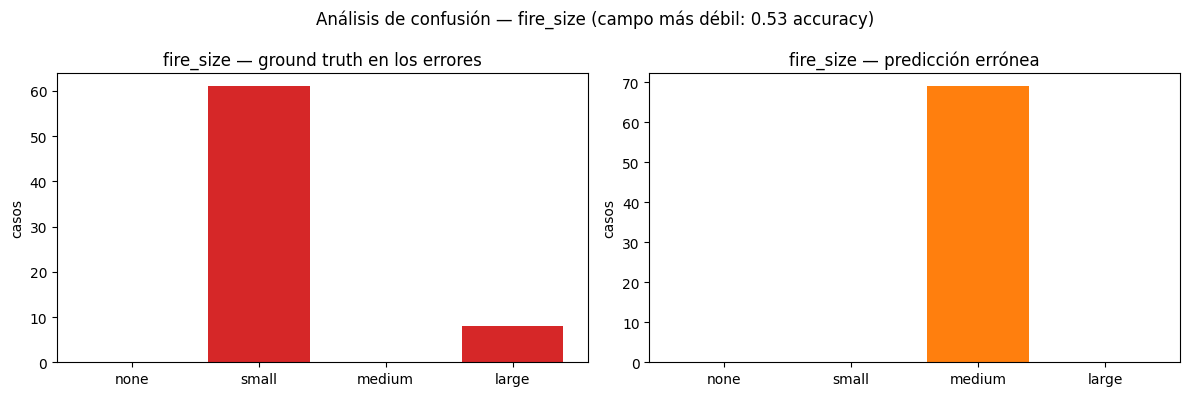

In [16]:
# ─── Distribución de errores de fire_size (campo más débil) ───────────────────
size_errors = errors["fire_size"]
pred_wrong  = Counter(r["pred"].get("fire_size", "None") for r in size_errors)
truth_wrong = Counter(r["truth"].get("fire_size", "None") for r in size_errors)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ["none", "small", "medium", "large"]

axes[0].bar(labels, [truth_wrong.get(l, 0) for l in labels], color="#d62728")
axes[0].set_title("fire_size — ground truth en los errores")
axes[0].set_ylabel("casos")

axes[1].bar(labels, [pred_wrong.get(l, 0) for l in labels], color="#ff7f0e")
axes[1].set_title("fire_size — predicción errónea")
axes[1].set_ylabel("casos")

plt.suptitle("Análisis de confusión — fire_size (campo más débil: 0.53 accuracy)", fontsize=12)
plt.tight_layout()
plt.show()

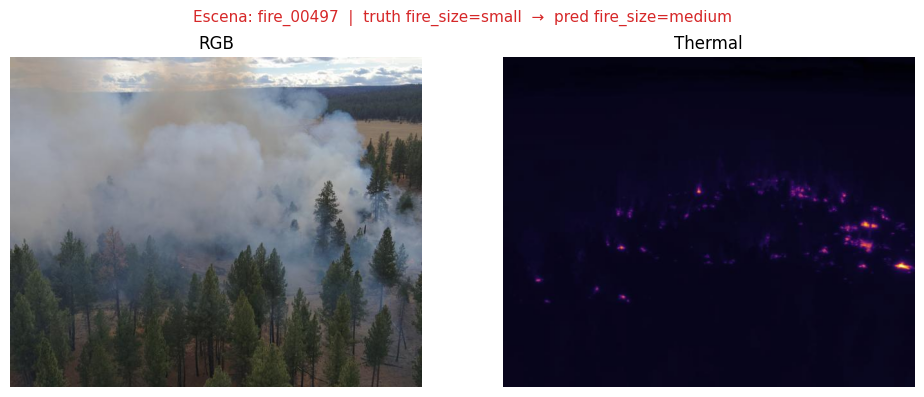

Truth: {
  "fire_present": true,
  "thermal_hotspot_intensity": "high",
  "fire_size": "small",
  "smoke_visible": true,
  "image_quality_limited": false
}
Pred:  {
  "fire_present": true,
  "thermal_hotspot_intensity": "high",
  "fire_size": "medium",
  "smoke_visible": true,
  "image_quality_limited": false
}


In [17]:
# ─── Ver un error de fire_size en detalle ─────────────────────────────────────
sample_error = size_errors[0]
scene = sample_error["scene"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(Image.open(IMAGES_DIR / f"{scene}_rgb.jpg"))
axes[0].set_title("RGB"); axes[0].axis("off")
axes[1].imshow(Image.open(IMAGES_DIR / f"{scene}_thermal.jpg"))
axes[1].set_title("Thermal"); axes[1].axis("off")

truth = sample_error["truth"]
pred  = sample_error["pred"]
plt.suptitle(
    f"Escena: {scene}  |  truth fire_size={truth['fire_size']}  →  pred fire_size={pred.get('fire_size','?')}",
    fontsize=11, color="#d62728"
)
plt.tight_layout(); plt.show()

print(f"Truth: {_json.dumps(truth, indent=2)}")
print(f"Pred:  {_json.dumps(pred, indent=2)}")

---
## 5. Distribución del dataset

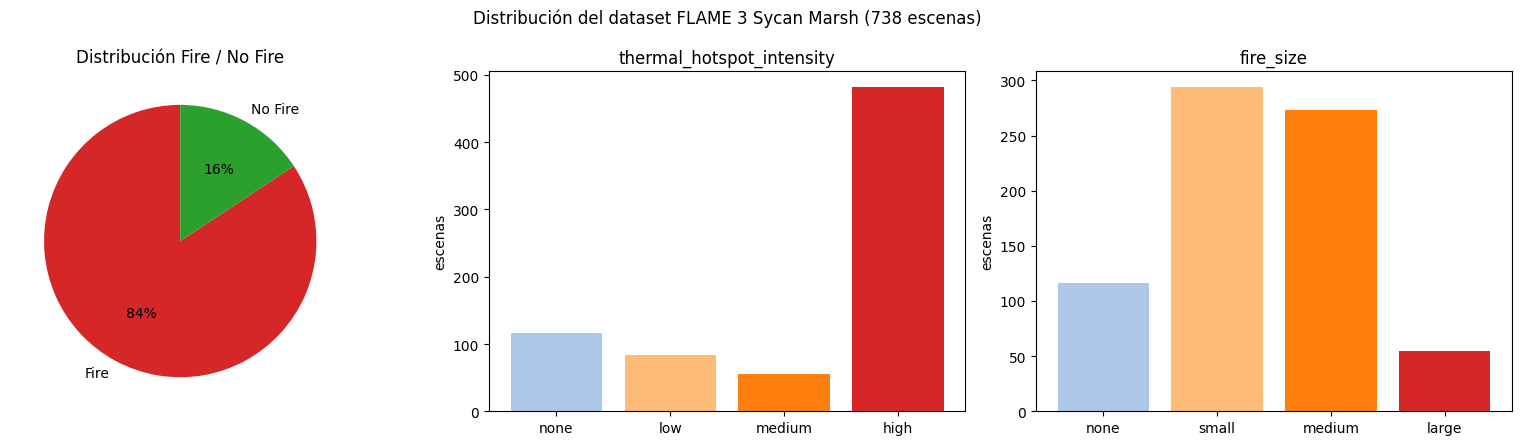

Total escenas: 738  |  Train: 591  |  Test: 147


In [18]:
import csv

split_rows = list(csv.DictReader((FT_DIR / "data" / "split.csv").open()))
labels_rows = list(csv.DictReader((FT_DIR / "data" / "labels.csv").open()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Distribución por categoría
cats = Counter(r["category"] for r in split_rows)
axes[0].pie(cats.values(), labels=cats.keys(),
            colors=["#d62728", "#2ca02c"], autopct="%1.0f%%", startangle=90)
axes[0].set_title("Distribución Fire / No Fire")

# Distribución thermal_hotspot_intensity
intensities = Counter(_json.loads(r["label_json"])["thermal_hotspot_intensity"] for r in labels_rows)
order_i = ["none", "low", "medium", "high"]
axes[1].bar(order_i, [intensities.get(k, 0) for k in order_i],
            color=["#aec7e8", "#ffbb78", "#ff7f0e", "#d62728"])
axes[1].set_title("thermal_hotspot_intensity")
axes[1].set_ylabel("escenas")

# Distribución fire_size
sizes = Counter(_json.loads(r["label_json"])["fire_size"] for r in labels_rows)
order_s = ["none", "small", "medium", "large"]
axes[2].bar(order_s, [sizes.get(k, 0) for k in order_s],
            color=["#aec7e8", "#ffbb78", "#ff7f0e", "#d62728"])
axes[2].set_title("fire_size")
axes[2].set_ylabel("escenas")

plt.suptitle("Distribución del dataset FLAME 3 Sycan Marsh (738 escenas)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Total escenas: {len(labels_rows)}  |  Train: {sum(1 for r in split_rows if r['split']=='train')}  |  Test: {sum(1 for r in split_rows if r['split']=='test')}")

---
## 6. Ver plots guardados

In [19]:
from IPython.display import display
import ipywidgets as widgets

plots = sorted(PLOTS_DIR.glob("*.png"))
print(f"Plots disponibles ({len(plots)}):")
for i, p in enumerate(plots):
    print(f"  [{i}] {p.name}")

Plots disponibles (6):
  [0] 00_training_sample.png
  [1] 01_loss_curve.png
  [2] 02_lr_schedule.png
  [3] 03_grad_norm.png
  [4] 04_field_accuracy.png
  [5] 05_overall.png


── 00_training_sample.png


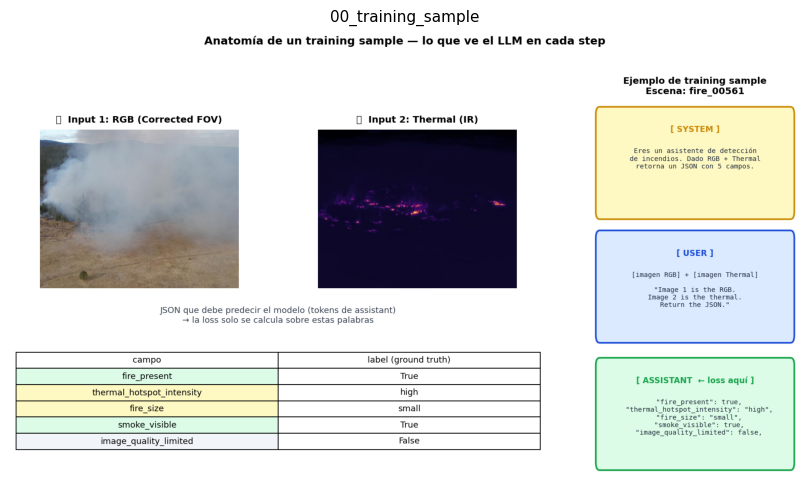

── 01_loss_curve.png


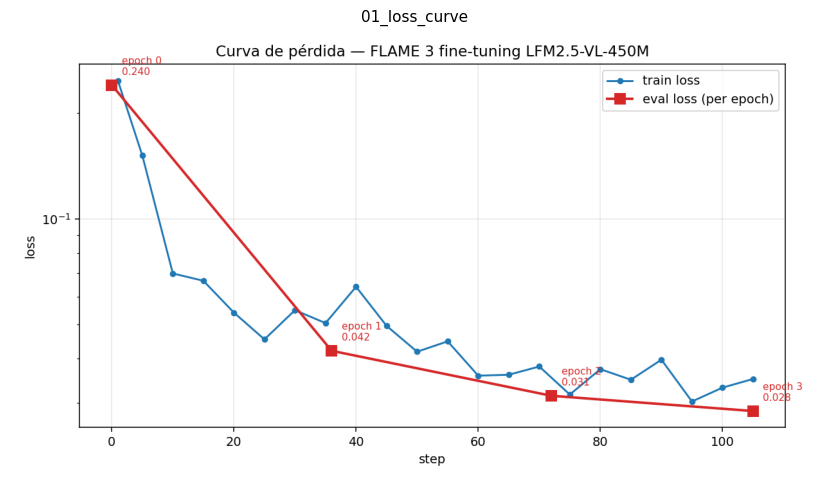

── 02_lr_schedule.png


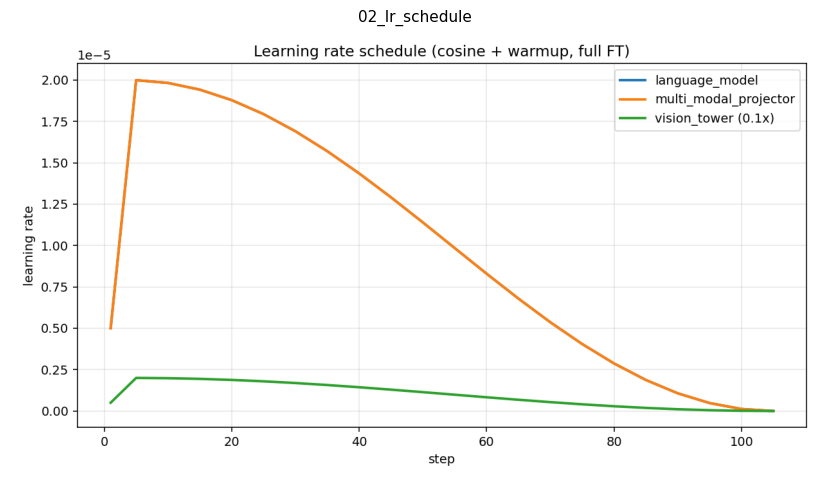

── 03_grad_norm.png


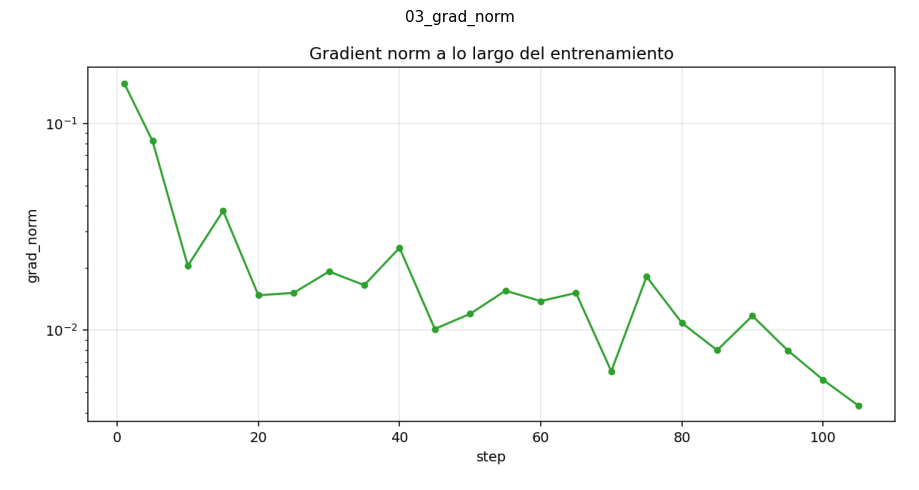

── 04_field_accuracy.png


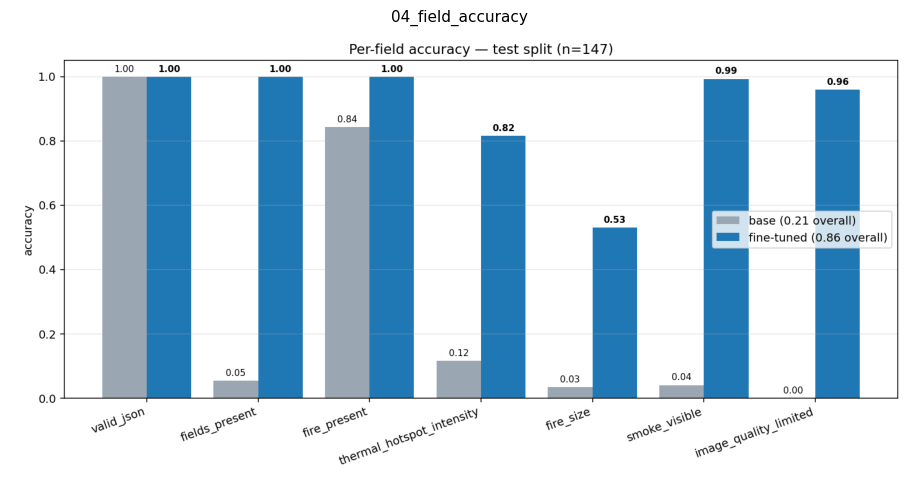

── 05_overall.png


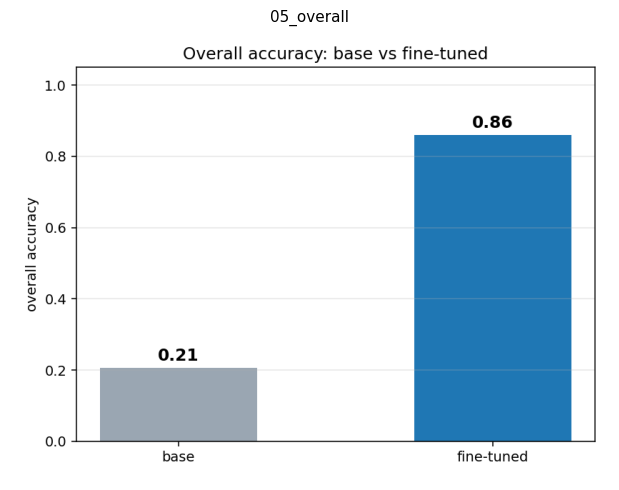

In [20]:
# Muestra todos los plots guardados
for p in sorted(PLOTS_DIR.glob("*.png")):
    print(f"── {p.name}")
    img = Image.open(p)
    plt.figure(figsize=(11, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(p.stem, fontsize=11)
    plt.tight_layout()
    plt.show()